In [2]:
import requests
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_absolute_percentage_error as mape
import seaborn as sns
import functions
import seaborn as sns

In [3]:
# pd.options.display.float_format = '{:,.3f}'.format  # Переустанавливаем формат
pd.options.display.float_format = '{:,.0f}'.format

In [4]:
jobs_df = pd.read_csv("jobs_df.csv")
jobs_df.head(3)

,premium,name,department,has_test,response_letter_required,area,address,employer,snippet,schedule,working_time_intervals,accept_temporary,professional_roles,experience,employment,key_skills,average_salary,min_salary,max_salary,hours_since_publication
0,False,Разработчик Python,NaN,False,False,Москва,NaN,Гриндата,"{'requirement': 'Python от 2х лет. FastAPI, Fl...",Полный день,NaN,False,"Программист, разработчик",От 1 года до 3 лет,Полная занятость,[],NaN,NaN,NaN,27
1,False,AI/ML Engineer Стажёр,NaN,False,False,Ташкент,NaN,YATT YULDASHEV PULAT BAXTIYOROVICH,{'requirement': 'Идеальный кандидат уже имеет ...,Гибкий график,Можно сменами по 4-6 часов в день,False,"Программист, разработчик",Нет опыта,Стажировка,"['Python', 'PostgreSQL', 'ORM', 'Git', 'ООП', ...",NaN,NaN,NaN,77
2,False,Python-разработчик,NaN,False,False,Москва,"{'city': 'Москва', 'street': 'Пресненская набе...",ВТБ Капитал,"{'requirement': 'Python (flask/django, multipr...",Полный день,NaN,False,"Программист, разработчик",Нет опыта,Полная занятость,"['Python', 'SQL', 'Flask', 'Django Framework']",NaN,NaN,NaN,122


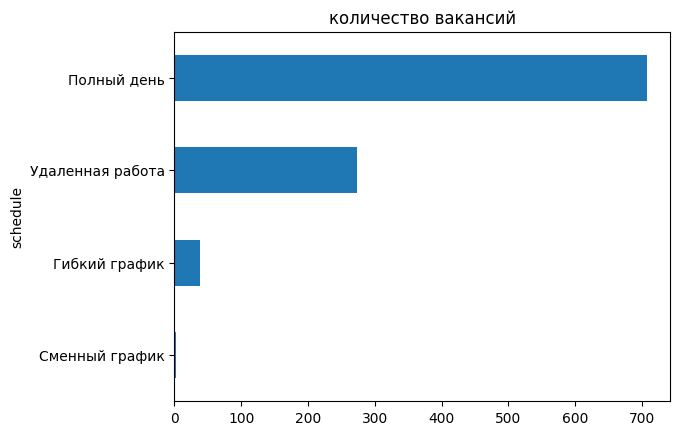

In [5]:
jobs_df['schedule'].value_counts().sort_values().plot.barh(title='количество вакансий')
plt.show()

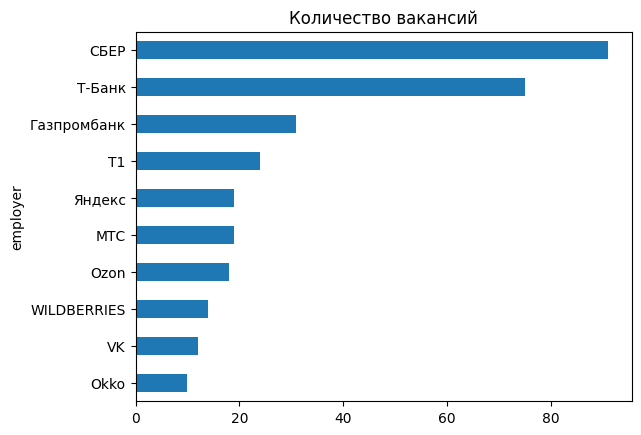

In [6]:
jobs_df.employer.value_counts().head(10).sort_values().plot.barh(title='Количество вакансий')
plt.show()

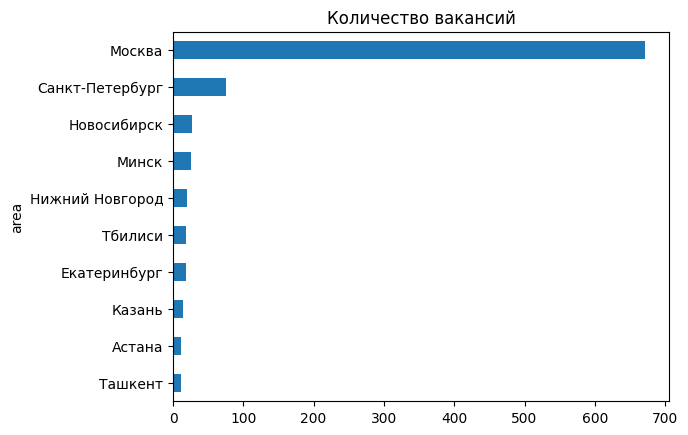

In [7]:
jobs_df.area.value_counts().head(10).sort_values().plot.barh(title='Количество вакансий')
plt.show()

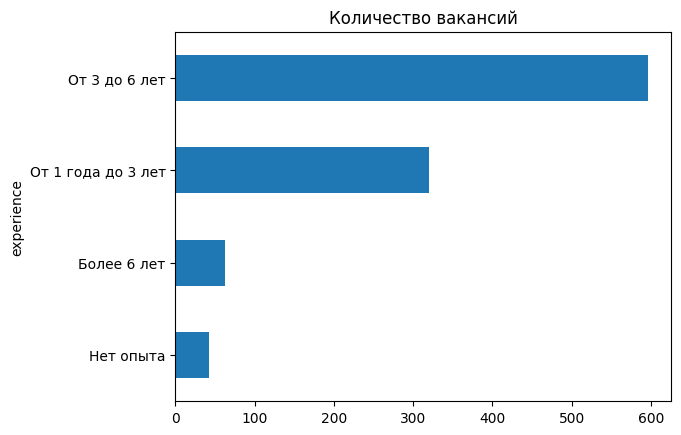

In [8]:
jobs_df.experience.value_counts().head(10).sort_values().plot.barh(title='Количество вакансий')
plt.show()

In [9]:
print('Количество вакансий с указанной зарплатой', (~jobs_df.average_salary.isna()).sum())
print('Доля вакансий с указанной зарплатой', format((~jobs_df.average_salary.isna()).mean(), '.2f'))

Количество вакансий с указанной зарплатой 148
Доля вакансий с указанной зарплатой 0.14


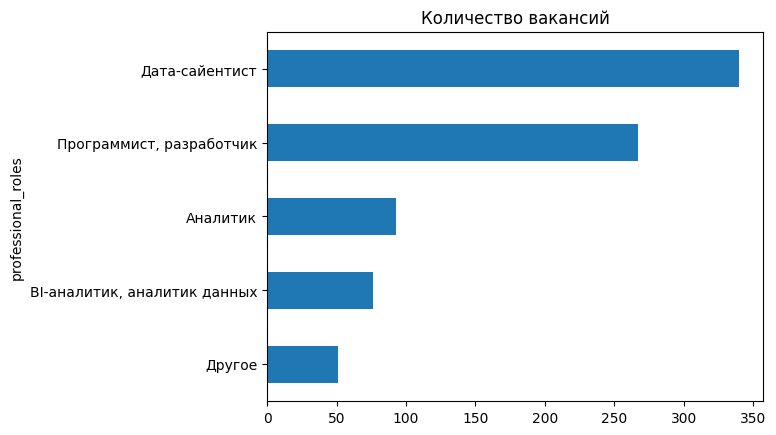

In [10]:
jobs_df.professional_roles.value_counts().head(5).sort_values().plot.barh(title='Количество вакансий')
plt.show()

In [11]:
functions.flatten_series(jobs_df.name.str.lower().str.split())\
.apply(lambda el: ''.join(char for char in el if char.isalnum()))\
.value_counts().head(20)

,count
data,412
engineer,296
scientist,261
ml,182
senior,133
в,122
,110
python,80
данных,78
middle,77


In [12]:
jobs_df['grade'] = jobs_df['name']\
.apply(lambda el: 'lead' if 'lead' in el.lower()
else 'middle_plus' if ('middle' in el.lower() and 'senior' in el.lower()) or 'middle+' in el.lower()
else 'senior' if 'senior' in el.lower()
else 'middle' if 'middle' in el.lower()
else 'junior' if 'junior' in el.lower()
else 'intern' if 'intern' in el.lower() or 'стажёр' in el.lower() or 'стажер' in el.lower()
else None)

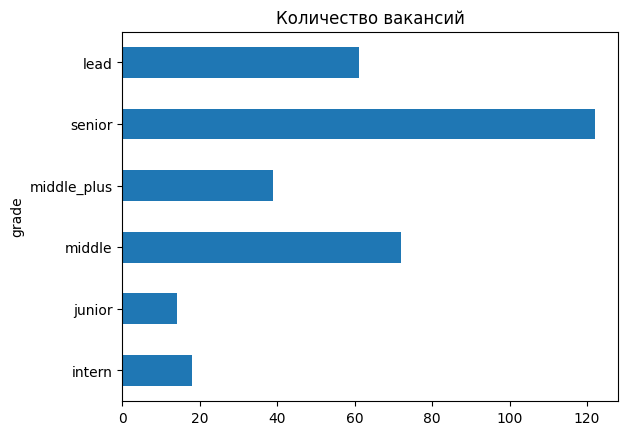

In [13]:
jobs_df.grade.value_counts()\
.loc[['intern',
      'junior',
      'middle',
      'middle_plus',
      'senior',
      'lead']].plot.barh(title='Количество вакансий')
plt.show()

In [14]:
jobs_df_f = jobs_df[~jobs_df['average_salary'].isna()]

In [15]:
X = jobs_df_f.drop(['average_salary', 'address', 'snippet', 'key_skills', 'min_salary',	'max_salary', 'hours_since_publication'], axis=1)
y = jobs_df_f['average_salary']

In [16]:
!pip install catboost
import catboost as cb
from sklearn.model_selection import cross_val_predict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 5.8 MB/s eta 0:00:00


In [17]:
model = cb.CatBoostRegressor(cat_features=X.columns.tolist(), silent=True, iterations=1000, depth=8)
y_pred = cross_val_predict(model, X.fillna('-'), y, cv=42)

In [18]:
print('mae', mae(y, y_pred))
print('mape', mape(y, y_pred))

mae 101658.23098918803
mape 0.992143561214861


In [19]:
model = cb.CatBoostRegressor(cat_features=X.columns.tolist(), silent=True, iterations=1000, depth=8)
model.fit(X.fillna('-'), y)

In [20]:
pd.DataFrame({'feature': model.feature_names_, 'importance': model.feature_importances_})\
.sort_values(by='importance', ascending=False)

,feature,importance
11,experience,28
13,grade,17
10,professional_roles,15
7,schedule,11
12,employment,8
5,area,8
2,department,5
8,working_time_intervals,3
6,employer,3
9,accept_temporary,1


In [21]:
X.drop(['premium', 'name', 'has_test', 'response_letter_required', 'working_time_intervals', 'employer'], axis=1, inplace=True)

In [22]:
model = cb.CatBoostRegressor(cat_features=pd.get_dummies(X).columns.tolist(), silent=True)
y_pred = cross_val_predict(model, pd.get_dummies(X), y, cv=42)
print('mae', mae(y, y_pred))
print('mape', mape(y, y_pred))

mae 102983.23513429496
mape 0.7685699957279591


In [23]:
model = cb.CatBoostRegressor(cat_features=pd.get_dummies(X).columns.tolist(), silent=True)
model.fit(pd.get_dummies(X), y)

In [24]:
jobs_dummies = pd.get_dummies(jobs_df[X.columns])
jobs_dummies_f = pd.get_dummies(X)

In [25]:
jobs_df['predict_salary'] = model.predict(jobs_dummies[jobs_dummies_f.columns]).astype(int)

<function matplotlib.pyplot.show(close=None, block=None)>

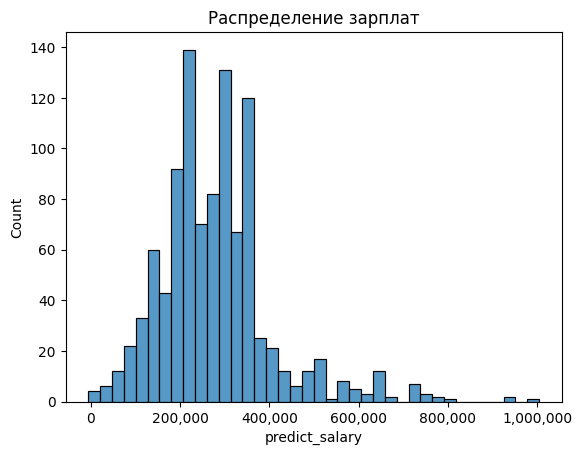

In [26]:
hist = sns.histplot(jobs_df['predict_salary'])
hist.set(title="Распределение зарплат")

import matplotlib.ticker as mtick
hist.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}')) # в начале зарплаты почему-то вывелись в формате 2.893174e+05, так что добавил такую обработку
plt.show

In [27]:
jobs_df['predict_salary'].describe()

,predict_salary
count,"1,021"
mean,"280,125"
std,"128,278"
min,"-5,536"
25%,"203,255"
50%,"275,208"
75%,"340,006"
max,"1,004,182"


In [36]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.base import BaseEstimator
from sklearn.model_selection import GridSearchCV

class GradientBoosting(BaseEstimator):  # BaseEstimator для совместимости с scikit-learn
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.models = []

    def fit(self, X, y):
        y_pred = np.zeros_like(y, dtype=np.float64)

        for _ in range(self.n_estimators):
            residuals = y - y_pred

            model = DecisionTreeRegressor(max_depth=self.max_depth)
            model.fit(X, residuals)

            self.models.append(model)
            y_pred += self.learning_rate * model.predict(X)

    def predict(self, X):
        y_pred = np.zeros(X.shape[0])
        for model in self.models:
            y_pred += self.learning_rate * model.predict(X)
        return y_pred

    def get_params(self, deep=True):
        return {
            'n_estimators': self.n_estimators,
            'learning_rate': self.learning_rate,
            'max_depth': self.max_depth
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

# Пример для поиска оптимальных гиперпараметров
param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(GradientBoosting(), param_grid, scoring='neg_mean_absolute_error', cv=5)
grid_search.fit(pd.get_dummies(X), y)

# print("Лучшие параметры:", grid_search.best_params_)
best_model = grid_search.best_estimator_

# model = GradientBoosting(n_estimators=300, learning_rate=0.05, max_depth=5, min_samples_leaf=10)
y_pred = cross_val_predict(best_model, pd.get_dummies(X), y, cv=16)
print('mae', mae(y, y_pred))
print('mape', mape(y, y_pred))


mae 96832.8149145472
mape 0.9156644440447619


Мне выдавало ошибку из-за того, что cross_val_predict в scikit-learn ожидает, что объект модели будет наследовать интерфейс scikit-learn и реализовывать методы get_params и set_params, так что я добавил их в модель

Я использовал CatBoost, потому что у меня почти все фичи категориальные, но я только что эта модель использует какой-то хитрый градиентовый бустинг. Я посмотрел большую лекцию про CatBoost и понял, что чтобы написать так же у меня уйдет миллион лет, поэтому я написал немного упрощенную версию, но сохраняющую суть модели - градиентовый бустинг над решающими деревьями

Параметры, которые были добавлены:
n_estimators — количество деревьев, learning_rate — скорость обучения .